In [1]:
from vision_transformer import *
from losses import *

import keras
import tensorflow as tf 

import matplotlib.pyplot as plt


In [2]:
model3, train_data, gt_train_labels, validation_data, gt_validation_labels = load_model_and_data()

In [3]:
train_data.shape

(1392, 304, 304, 3)

In [4]:
model3.summary()

Model: "ViT_early_conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 304, 304, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 304, 304, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 304, 304, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 304, 304, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 304, 304, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 304, 304, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 304, 304, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 304, 304, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 304, 304, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 152, 152, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 152, 152, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 19, 19, 16)     │         3,904 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 19, 19, 16)     │         3,904 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 19, 19, 16)     │         3,904 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 19, 19, 16)     │         3,904 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 19, 19, 16)     │         3,904 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 19, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,089 (94.10 KB)

 Trainable params: 23,641 (92.35 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
train = True

filename = 'vitc_B5_e20_b64_f1loss'

if train:

    # Compile the model
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,     # maybe 0.001 is better
        decay_steps=60,
        decay_rate=0.95,
        staircase=True
    )

    # Defining optimizer
    opt = keras.optimizers.Adam(learning_rate=lr_schedule)
    model3.compile(
        optimizer=opt,
        #loss=soft_dice_loss,        # OR loss=soft_f1_loss
        loss=soft_f1_loss,
        metrics=[f1_metric],
    )

    # Training the model
    history = model3.fit(
    train_data, gt_train_labels,
    epochs=20,
    batch_size=64,
    validation_data=(validation_data, gt_validation_labels),
    verbose=1
    )

    # Plot the loss
    plt.plot(history.history['loss'], label='Training loss')
    plt.plot(history.history['val_loss'], label = 'Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('ML_plots/' + filename + '_loss.png')
    plt.show()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 197s 8s/step - f1_metric: 0.3502 - loss: 0.2916 - val_f1_metric: 0.3879 - val_loss: 0.3277
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - f1_metric: 0.1603 - loss: 0.1566 - val_f1_metric: 0.3879 - val_loss: 0.3890
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 196s 8s/step - f1_metric: 0.0565 - loss: 0.0755 - val_f1_metric: 0.3879 - val_loss: 0.3890
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 281s 12s/step - f1_metric: 0.0345 - loss: 0.0487 - val_f1_metric: 0.3879 - val_loss: 0.3890
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 232s 10s/step - f1_metric: 0.0235 - loss: 0.0342 - val_f1_metric: 0.3879 - val_loss: 0.3890
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 202s 9s/step - f1_metric: 0.0181 - loss: 0.0263 - val_f1_metric: 0.3879 - val_loss: 0.3890
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 176s 8s/step - f1_metric: 0.0127 - loss: 0.0199 - val_f1_metric: 0.3879 - val_loss: 0.3890
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 168s 7s/step - f1_metric: 0.0094 - loss: 0.0159 - val_f1_

KeyboardInterrupt: 

In [6]:
# Save the model
model3.save_weights('./model_weights/' + filename + '.weights.h5')

In [7]:
if not train:
    model3.load_weights('./model_weights/' + filename + '.weights.h5')

In [ ]:
# Compute the number of True positives, False positives and False negatives for the validation set
gt_validation_predictions = model3.predict(validation_data)

tp = tf.reduce_sum(gt_validation_labels * gt_validation_predictions)
fp = tf.reduce_sum((1 - gt_validation_labels) * gt_validation_predictions)
fn = tf.reduce_sum(gt_validation_labels * (1 - gt_validation_predictions))

precision = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)
f1 = 2 * precision * recall / (precision + recall + 1e-7)

metrics = [precision, recall, f1, tp, fp, fn]


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 822ms/step


In [9]:
print([float(metric) for metric in metrics])

[0.257729172706604, 1.0, 0.40983250737190247, 32378.0, 93250.0, 0.0]


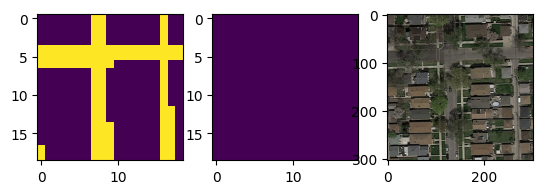

In [ ]:
i = 6
plt.subplot(1, 3, 1)
plt.imshow(gt_validation_labels[i])
plt.subplot(1, 3, 2)
plt.imshow(gt_validation_predictions[i].reshape(19, 19))
plt.subplot(1, 3, 3)
plt.imshow(validation_data[i])

In [11]:
# Extract the test data
TEST_SIZE = 50  # Size of the test data   
test_data = extract_test_data("test_set_images/", TEST_SIZE)

first_test_data_patches, second_test_data_patches, third_test_data_patches, fourth_test_data_patches = crop_test_data(test_data)

In [ ]:
# Predict for the test data
first_gt_test_predicted_labels = model3.predict(first_test_data_patches)
second_gt_test_predicted_labels = model3.predict(second_test_data_patches)
third_gt_test_predicted_labels = model3.predict(third_test_data_patches)
fourth_gt_test_predicted_labels = model3.predict(fourth_test_data_patches)

# Combine the predictions
gt_test_predicted_labels = np.zeros((TEST_SIZE, 38, 38))

for i in range(TEST_SIZE):
    gt_test_predicted_labels[i][:19, :19] = first_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][:19, 19:] = second_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, :19] = third_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, 19:] = fourth_gt_test_predicted_labels[i].reshape(19, 19)
    
gt_test_predicted_labels.shape

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 496ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 460ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 449ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step


(50, 38, 38)

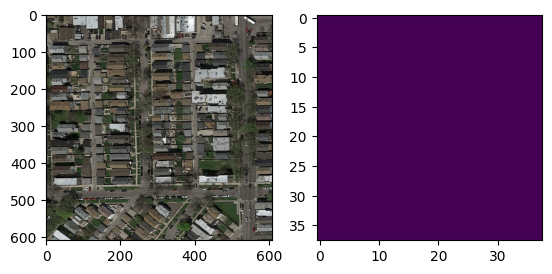

In [ ]:
# Display the first image and the label
i = 6
image = test_data[i]
prediction = gt_test_predicted_labels[i]
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(prediction)

In [14]:
# Denoise the predictions
denoised_test_predicted_labels = denoise(gt_test_predicted_labels)

In [15]:
# Create csv submission
submission_filename = "submissions/"+ filename +".csv"
create_csv_submission(submission_filename, denoised_test_predicted_labels)

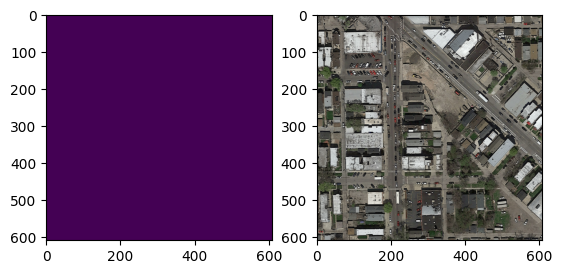

In [16]:

# Reconstruct the images from submission
im_index = 11 #   must be >0
im = reconstruct_from_labels(im_index, submission_filename)
plt.subplot(1, 2, 1)
plt.imshow(im)
plt.subplot(1, 2, 2)
plt.imshow(test_data[im_index - 1])
plt.savefig('ML_plots/' + filename + f'_exp_{im_index}.png')